# Part 1 → Theory Revision (Quick Recap)

## What is Chi-Square Distribution?

The **Chi-Square Distribution (χ²)** is a **continuous probability distribution**.

It is mainly used to analyze **categorical data** and to measure the difference between **Observed** values and **Expected** values.

Unlike the Normal Distribution, the Chi-Square Distribution is **not symmetric**.

It always starts from **0** and extends toward positive values.

### AI/ML Use

Chi-Square Distribution is commonly used for:

- Feature Selection
- Hypothesis Testing
- Categorical Data Analysis
- Independence Testing
- Model Evaluation

---

## Why is it called Chi-Square?

It is called **Chi-Square (χ²)** because its statistic is calculated by squaring the difference between the **Observed** and **Expected** values.

### Formula

$$
\chi^2=\sum\frac{(O-E)^2}{E}
$$

Where:

- **O** = Observed Value
- **E** = Expected Value

Since the difference is squared:

- Negative values become positive.
- The Chi-Square statistic is always **0 or greater**.

---

## Right-Skewed Distribution

The Chi-Square Distribution is **right-skewed**.

This means:

- Most probability is concentrated on the left.
- A long tail extends toward the right.
- Negative values are not possible.

### Observation

- Small **df** → Highly right-skewed.
- Large **df** → More symmetric and closer to a Normal Distribution.

---

## Degrees of Freedom (df)

### What is df?

Degrees of Freedom (**df**) represent the amount of independent information available for analysis.

For many Chi-Square problems,

$$
df=n-1
$$

For a contingency table,

$$
df=(r-1)(c-1)
$$

Where:

- **r** = Number of rows
- **c** = Number of columns

### Effect of df

- Small df → More skewed graph.
- Large df → Less skewed graph.
- Increasing df shifts the peak to the right.

### AI/ML Use

Degrees of Freedom affect the critical value and statistical decision during hypothesis testing.

---

## Shape of the Distribution

The shape depends mainly on **Degrees of Freedom**.

### Small df

- High peak near zero.
- Long right tail.
- More skewed.

### Large df

- Peak moves right.
- Distribution becomes smoother.
- Looks closer to the Normal Distribution.

---

## Mean

The mean of a Chi-Square Distribution is:

$$
\mu=df
$$

### Meaning

The average value of the distribution is equal to its Degrees of Freedom.

---

## Variance

The variance is:

$$
\sigma^2=2df
$$

### Meaning

As **df** increases:

- Variance increases.
- The distribution becomes wider.

---

## Chi-Square Statistic

The Chi-Square Statistic measures how different the **Observed** values are from the **Expected** values.

### Formula

$$
\chi^2=\sum\frac{(O-E)^2}{E}
$$

### Simple Interpretation

- Small χ² → Observed values are close to Expected values.
- Large χ² → Observed values are very different from Expected values.

---

## Expected vs Observed Values

### Observed Values (O)

These are the actual values collected from the dataset.

Example:

A survey records:

- Male = 60
- Female = 40

These are the **Observed Values**.

### Expected Values (E)

Expected values are the values we would expect if there were **no relationship** or **no difference**.

Example:

If we expect an equal distribution:

- Male = 50
- Female = 50

These are the **Expected Values**.

### Why Compare Them?

The Chi-Square test checks whether the difference between **Observed** and **Expected** values is large enough to be statistically significant.

### AI/ML Use

This comparison helps identify whether a categorical feature is useful for prediction.

---

## When to Use Chi-Square Distribution?

Use the Chi-Square Distribution when:

- Data is **categorical**.
- You want to compare **Observed** and **Expected** values.
- You are performing **Hypothesis Testing**.
- You want to test whether two categorical variables are independent.
- You want to select important categorical features before training a Machine Learning model.

### Common AI/ML Applications

- Feature Selection (`SelectKBest`)
- Customer Behaviour Analysis
- Medical Research
- Fraud Detection
- Marketing Analysis
- Survey Analysis
- Recommendation Systems
- A/B Testing
- Classification Problems

---

# Quick Revision

- Chi-Square works with **categorical data**.
- It compares **Observed** and **Expected** values.
- The graph is **right-skewed**.
- The graph starts from **0** and never becomes negative.
- Degrees of Freedom control the shape of the graph.
- Small **df** → More skewed.
- Large **df** → Closer to a Normal Distribution.
- A larger Chi-Square statistic means a larger difference between Observed and Expected values.
- Chi-Square is one of the most important statistical tools for **Feature Selection**, **Hypothesis Testing**, and **Categorical Data Analysis** in AI/ML.

# Part 2 → Generate Dataset 

**Objective**   

In this section, we will generate a categorical dataset that can be used for Chi-Square Analysis.   

We will create a dataset, understand its categories, build a contingency table, and prepare it for hypothesis testing.

### Step 1 → Import Libraries

In [1]:
import numpy as np
import pandas as pd

**Why?**    

- **NumPy** → Generate random categorical data.
- **Pandas** → Create and manage the dataset.

### Step 2 → Set Random Seed

In [2]:
np.random.seed(42)

**Why?**

Every time you run the notebook, the same dataset will be generated.

This makes your experiment reproducible.

### Step 3 → Generate Dataset   

Suppose an e-commerce company wants to analyze: 

**Does Gender affect product Purchase?**

In [3]:
gender = np.random.choice(
    ["Male", "Female"],
    size=500,
    p=[0.55,0.45]
)

purchase = np.random.choice(
    ["Yes","No"],
    size=500,
    p=[0.65,0.35]
)

**Explanation**

Gender

Possible categories

- Male
- Female    

```py 
size=500    
``` 

Generate **500 customers.** 

```py   
p=[0.55,0.45]   
``` 

Means   

- 55% Male
- 45% Female

**Purchase**

Possible categories

- Yes
- No

```py
p=[0.65,0.35]   
```

Means

- 65% purchased
- 35% did not purchase

### Step 4 → Create DataFrame

In [4]:
df = pd.DataFrame({
    "Gender": gender,
    "Purchase": purchase
})

**Why?**

Now both columns become one dataset.    

| Gender | Purchase |
| ------ | -------- |
| Male   | Yes      |
| Female | No       |
| Male   | Yes      |

### Step 5 → Preview Dataset

In [5]:
df.head()

,Gender,Purchase
0,Male,No
1,Female,Yes
2,Female,Yes
3,Female,No
4,Male,No


In [6]:
df.tail()

,Gender,Purchase
495,Male,Yes
496,Female,No
497,Male,Yes
498,Female,No
499,Female,Yes


In [7]:
df.sample(5)

,Gender,Purchase
42,Male,Yes
295,Male,No
479,Male,Yes
54,Female,No
333,Male,Yes


### Step 6 → Understand Categories

In [8]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [9]:
df["Purchase"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Why?

Before applying Chi-Square, always know your categories.

### Step 7 → Create Contingency Table

In [10]:
contingency_table = pd.crosstab(
    df["Gender"],
    df["Purchase"]
)

contingency_table

Purchase,No,Yes
Gender,,
Female,68,160
Male,88,184


**Why is this important?**  

Chi-square Test works on a **Contingency table**, not directly on the raw dataset.      

this table contains the **Observed Frequencies.**


### Part 2 Final Observation    

- ✅ Categorical Dataset
- ✅ Two categorical features
- ✅ Contingency Table
- ✅ Ready for Chi-Square Test

# Part 3 → Understand Dataset   

**Objective**   

In this section, we will explore the dataset before perfroming the chi-square test. 

This is the EDA(Exploratory Data Analysis) step.

### 1. Dataset Shape

In [11]:
df.shape

(500, 2)

Why?

Shows

- Number of rows
- Number of columns

Example

```
(500,2)
```

Meaning

500 observations

2 features

### 2. Head & Tail

In [12]:
df.head()

,Gender,Purchase
0,Male,No
1,Female,Yes
2,Female,Yes
3,Female,No
4,Male,No


In [13]:
df.tail()

,Gender,Purchase
495,Male,Yes
496,Female,No
497,Male,Yes
498,Female,No
499,Female,Yes


**Why?**

Quickly inspect the dataset.

### 3. Data Types

In [14]:
df.dtypes

Gender      str
Purchase    str
dtype: object

### Why?

Chi-Square works with categorical variables.

The columns may have data types like:

- object
- string (or str)
- category

All of these represent categorical text data and can be used for Chi-Square analysis.

### 4. Summary Statistics

In [15]:
df.describe(include="all")

,Gender,Purchase
count,500,500
unique,2,2
top,Male,Yes
freq,272,344


### 5. Value Counts

In [16]:
df["Gender"].value_counts()

Gender
Male      272
Female    228
Name: count, dtype: int64

In [17]:
df["Purchase"].value_counts()

Purchase
Yes    344
No     156
Name: count, dtype: int64

#### Why?

Shows how many times each category appears.

### 6. Frequency Table

In [18]:
pd.crosstab(
    df["Gender"],
    df["Purchase"]
)

Purchase,No,Yes
Gender,,
Female,68,160
Male,88,184


#### Why?

Shows the relationship between two categorical variables.

This is the **Observed Frequency Table.**

### 7. Contingency Table

In [19]:
contingency_table = pd.crosstab(
    df["Gender"],
    df["Purchase"]
)

contingency_table

Purchase,No,Yes
Gender,,
Female,68,160
Male,88,184


### 8. Expected Frequencies

In [20]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

expected

array([[ 71.136, 156.864],
       [ 84.864, 187.136]])

#### Why?

This calculates the **Expected Frequency Table.**   

Example 

|category|   No |   Yes |
| ------ | ---: | ----: |
| Female | 71.136 | 156.864 |
| Male   | 84.864 | 187.136 |

Now We can Compare: 
- **Observerd Values**
- **Expected Values**   

This is the core idea behind the Chi-Square Test.

#### Part 4 Final Observation   

Before applying the Chi-Square Test, always verify:

- ✅ Dataset contains categorical variables.
- ✅ Categories are correct.
- ✅ Frequency table is created.
- ✅ Contingency table is ready.
- ✅ Expected frequencies are calculated.
- ✅ Chi-Square assumptions are satisfied.

# Part 4 → Visualize    

**Objective**   

In this section, we visualize the Chi-Square Distribution and understand how it behaves for differnet Degrees of Freedom (df).  

We also compare the theoretical Distribution with the real categorical data.    

In [21]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Bar Chart    

**WHy?**    

A Bar chart shows the frequency of each category.   

This is the simplest visuaLization for cateogrical data.    

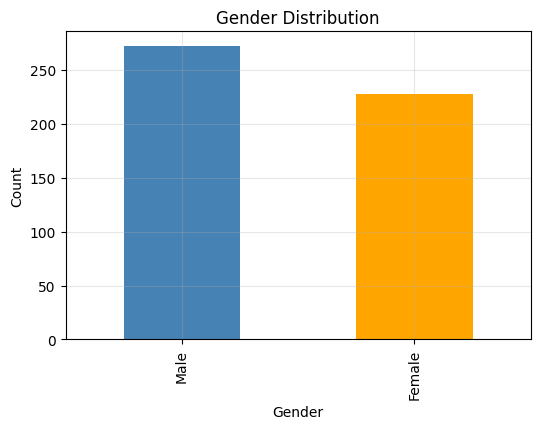

In [22]:

df["Gender"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue","orange"]
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(alpha=0.3)

plt.show()

**Interpretation**  
- Taller bar → More observation.    
- Shorter bar → Fewer observation.  
- Helps detects class imbalance.

### 2. Count Plot   

Why?    

CountPlot is the seaborn version of a bar chart.    

useful for comparing categorical variables.

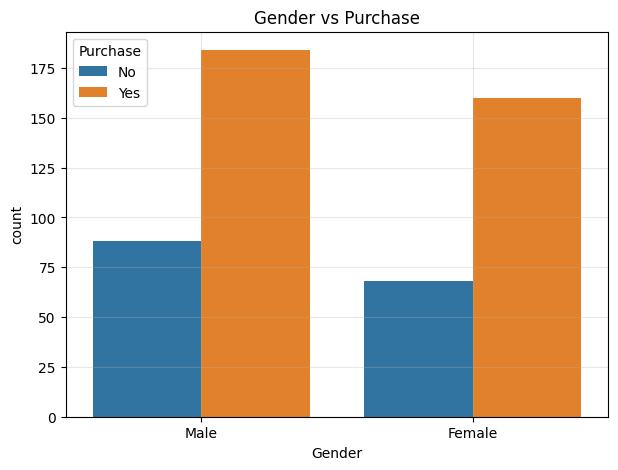

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Purchase"
)

plt.title("Gender vs Purchase")

plt.grid(alpha=0.3)

plt.show()

**Interpretation**  

Observe:    
- Which gender purchases more?  
- Which category has higher frequency?  
- Is there any visible relationship?

### 3. Observed vs Expected Chart

**Why?**

This is one of the most important Chi-Square graphs.

It compares:

- Observed Frequency
- Expected Frequency

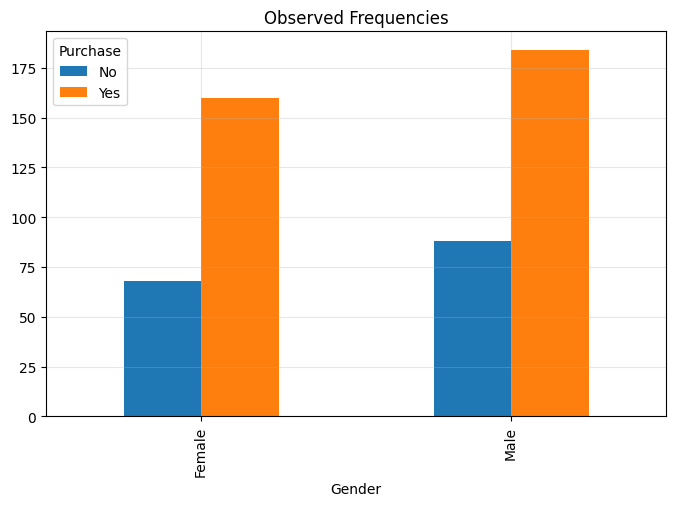

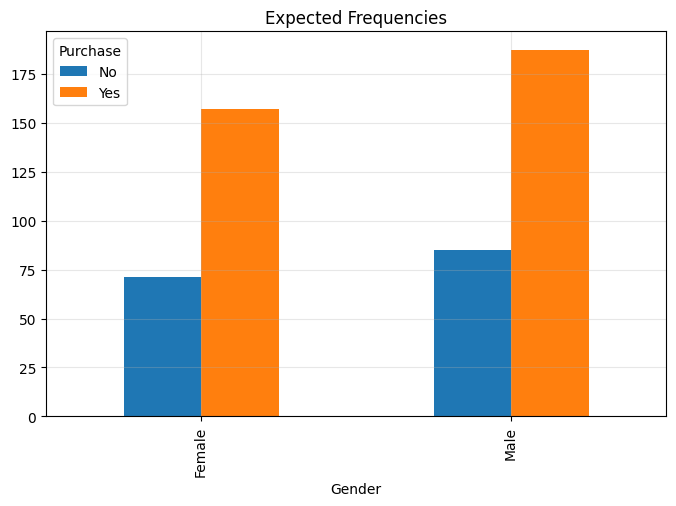

In [24]:
observed = contingency_table

expected_df = pd.DataFrame(
    expected,
    columns=observed.columns,
    index=observed.index
)

observed.plot(kind="bar", figsize=(8,5))

plt.title("Observed Frequencies")
plt.grid(alpha=0.3)

plt.show()

expected_df.plot(kind="bar", figsize=(8,5))

plt.title("Expected Frequencies")
plt.grid(alpha=0.3)

plt.show()

**Interpretation**

If observed values are very different from expected values,

↓

Chi-Square statistic becomes larger.

### 4. Chi-Square PDF   

**Why?**    

Shows the theoretical Chi-Square Distribution.

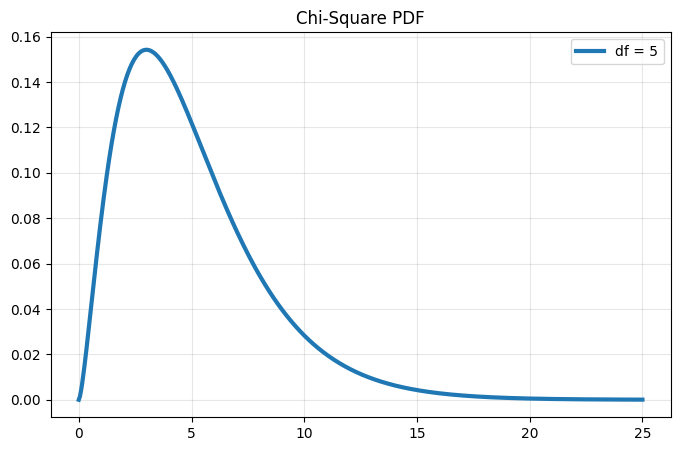

In [25]:
from scipy.stats import chi2

x=np.linspace(0,25,500)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    chi2.pdf(x,df=5),
    linewidth=3,
    label="df = 5"
)

plt.title("Chi-Square PDF")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

**Interpretation**

Notice:

- Starts at zero.
- Never goes below zero.
- Right-skewed.

### 5. Multiple Degrees of Freedom Comparison

Why?

Shows how df changes the graph.

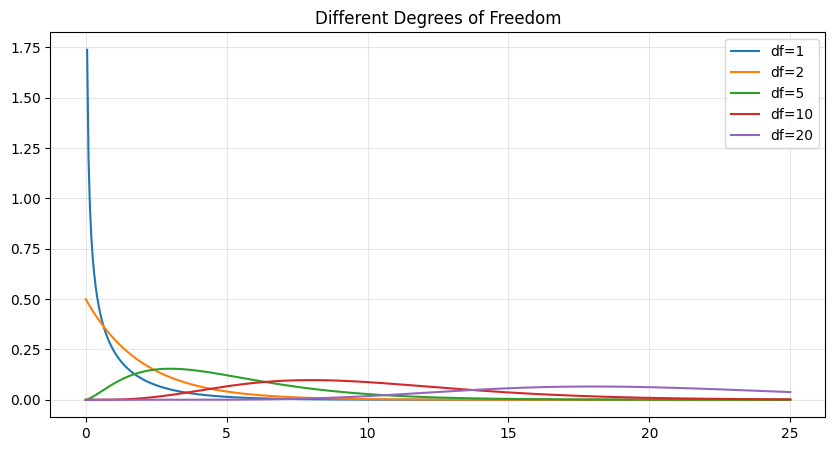

In [26]:
plt.figure(figsize=(10,5))

for df_value in [1,2,5,10,20]:

    plt.plot(
        x,
        chi2.pdf(x,df=df_value),
        label=f"df={df_value}"
    )

plt.legend()

plt.grid(alpha=0.3)

plt.title("Different Degrees of Freedom")

plt.show()

**Interpretation**

Observe:

- Small df → High peak + long tail.
- Large df → Curve becomes smoother.
- Large df → Looks closer to Normal Distribution.

### 6. Right-Skewed Shape Analysis

Why?

To clearly understand the skewness.

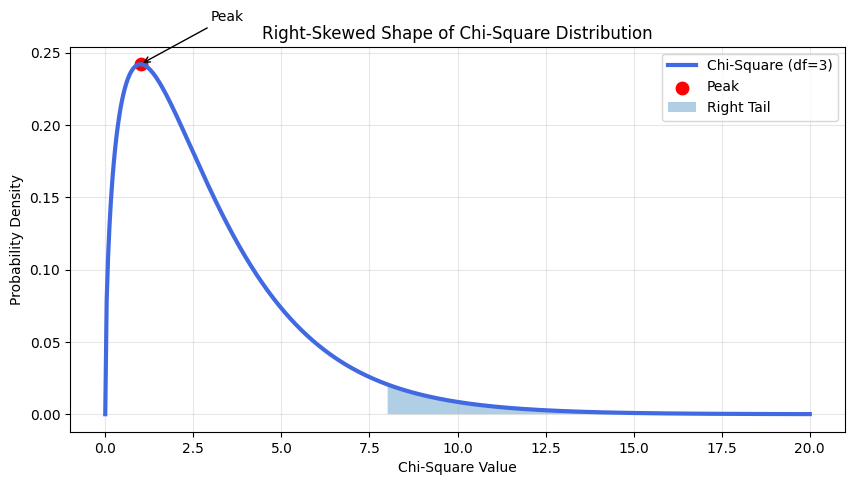

In [27]:
from scipy.stats import chi2
import numpy as np

# X-axis values
x = np.linspace(0, 20, 500)

# Degrees of Freedom
df = 3

# Chi-Square PDF
y = chi2.pdf(x, df=df)

plt.figure(figsize=(10, 5))

# Plot PDF
plt.plot(
    x,
    y,
    color="royalblue",
    linewidth=3,
    label=f"Chi-Square (df={df})"
)

# Peak Point
peak_x = x[np.argmax(y)]
peak_y = max(y)

plt.scatter(
    peak_x,
    peak_y,
    color="red",
    s=80,
    label="Peak"
)

# Annotation for Peak
plt.annotate(
    "Peak",
    xy=(peak_x, peak_y),
    xytext=(peak_x + 2, peak_y + 0.03),
    arrowprops=dict(arrowstyle="->")
)

# Shade Right Tail
plt.fill_between(
    x,
    y,
    where=(x > 8),
    alpha=0.35,
    label="Right Tail"
)

plt.title("Right-Skewed Shape of Chi-Square Distribution")

plt.xlabel("Chi-Square Value")

plt.ylabel("Probability Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Right-Skewed Shape Analysis

### What should you observe from this graph?

### ✅ 1. Peak is Near the Left

- The highest point of the graph is near the left side.
- Most observations are close to smaller values.
- Small Chi-Square values have the highest probability.

---

### ✅ 2. Tail Extends to the Right

- The curve becomes longer on the right side.
- Large Chi-Square values are possible.
- But their probability is much lower.

---

### ✅ 3. No Negative Values

- The graph starts from **0**.
- Chi-Square values cannot be negative.
- All values are **0 or positive**.

---

### ✅ 4. Right-Skewed Shape

- The left side of the graph is steep.
- The right side has a long tail.
- This is why it is called a **Right-Skewed Distribution**.

---

### ✅ 5. Compare with Normal Distribution

| Normal Distribution | Chi-Square Distribution |
|---------------------|-------------------------|
| Symmetric curve | Right-skewed curve |
| Mean is at the center | Peak is near the left |
| Can have negative values | Cannot have negative values |
| Bell-shaped curve | Long right tail |

---

## Quick Summary

- Most values are close to **0**.
- The graph has a **long right tail**.
- Negative values are **not possible**.
- Increasing **Degrees of Freedom (df)** makes the graph less skewed.
- With large **df**, the Chi-Square curve becomes closer to a Normal Distribution.

### 7. Effect of df on Curve    

| df Increase | Effect          |
| ----------- | --------------- |
| Peak        | Moves right     |
| Tail        | Becomes shorter |
| Shape       | Less skewed     |
| Spread      | Increases       |
| Symmetry    | Improves        |


### 8. Critical Region Visualization

Why?

Hypothesis testing depends on the critical region.

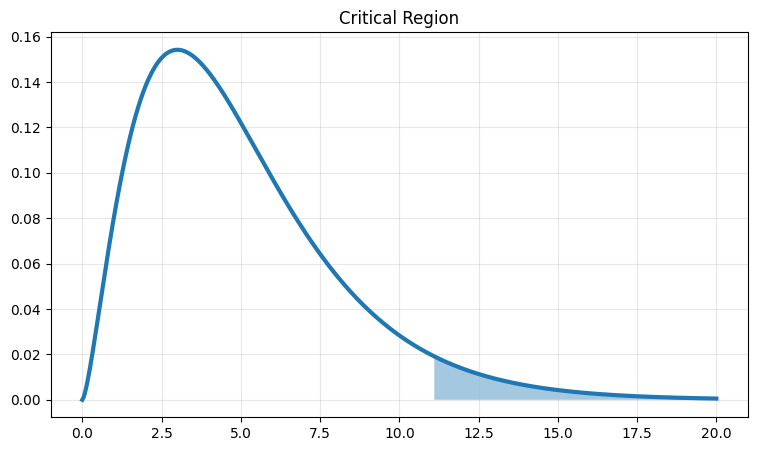

In [28]:
plt.figure(figsize=(9,5))

plt.plot(
    x,
    chi2.pdf(x,df=5),
    linewidth=3
)

plt.fill_between(
    x,
    chi2.pdf(x,df=5),
    where=(x>11.07),
    alpha=0.4
)

plt.title("Critical Region")

plt.grid(alpha=0.3)

plt.show()

**Interpretation**

The shaded area is called the Critical Region.

If the Chi-Square statistic falls here,

↓

Reject the Null Hypothesis.

### Part 4 Final Observation    

While reading a Chi-Square graph always check:

- Right-skewed or not?
- Peak location
- Tail length
- Degrees of Freedom
- Spread
- Critical region
- Does the graph become more symmetric?

# Part 5 → Parameter Analysis

## Objective

This section explains how different parameters affect the Chi-Square Distribution and its graph.

By changing these parameters, we can understand how the distribution behaves in different situations.

---

## 1. Degrees of Freedom (df)

### What is df?

Degrees of Freedom (**df**) controls the shape of the Chi-Square Distribution.

### Formula

$$
df = n - 1
$$

For a contingency table:

$$
df = (r - 1)(c - 1)
$$

Where:

- **r** = Number of rows
- **c** = Number of columns

### Effect on Graph

**Small df**

- Graph is highly right-skewed.
- Peak is close to zero.
- Right tail is long.

**Large df**

- Peak moves to the right.
- Graph becomes less skewed.
- Shape becomes closer to the Normal Distribution.

### AI/ML Use

Degrees of Freedom is used to calculate the **critical value** in Chi-Square hypothesis testing.

---

## 2. Observed Frequency

### What is it?

Observed Frequency is the **actual count** collected from the dataset.

Example

| Purchase | Count |
| -------- | ----: |
| Yes      |   320 |
| No       |   180 |

### Effect

If the Observed Frequency is very different from the Expected Frequency,

↓

The Chi-Square Statistic becomes larger.

---

## 3. Expected Frequency

### What is it?

Expected Frequency is the count we expect if there is **no relationship** between the variables.

### Effect

Observed ≈ Expected

↓

Small Chi-Square value

Observed is far from Expected

↓

Large Chi-Square value

### AI/ML Use

Expected Frequency helps determine whether two categorical variables are independent or related.

---

## 4. Sample Size

### What is Sample Size?

Sample Size is the total number of observations in the dataset.

### Effect

**Small Sample**

- Less reliable results.
- More random variation.

**Large Sample**

- More stable results.
- Better statistical power.
- More reliable conclusions.

### AI/ML Use

Large datasets usually produce more accurate statistical analysis and better machine learning models.

---

## 5. Random Seed

### Why?

```python
np.random.seed(42)
```

Using the same seed gives:

- Same dataset.
- Same graph.
- Same experiment every time.

### AI/ML Use

Random Seed is important for reproducible experiments and research.

---

## 6. bins

### What are bins?

Bins divide the histogram into groups.

### Effect

**Few bins**

- Simple graph.
- Less detail.

**Many bins**

- More detail.
- Graph may become noisy.

### Best Practice

```python
bins = 20
```

Usually **20–30 bins** give a clear visualization.

---

## 7. density

### What is density?

Density changes the histogram from frequency to probability density.

```python
density=False
```

Y-axis → Frequency

```python
density=True
```

Y-axis → Probability Density

### AI/ML Use

Useful when comparing the histogram with the theoretical Chi-Square PDF.

---

## 8. alpha

### What is alpha?

Alpha controls the transparency of the graph.

```python
alpha=0.5
```

### Effect

Small alpha

- More transparent.

Large alpha

- More visible.

Useful when comparing multiple graphs.

---

## 9. linewidth

### What is linewidth?

Linewidth controls the thickness of a line.

```python
linewidth=2
```

### Effect

Small value

- Thin line.

Large value

- Thick line.

Makes graphs easier to read.

---

## 10. Effect of df on Graph

| df | Graph Shape |
|----|-------------|
| 1 | Very right-skewed |
| 2 | Right-skewed |
| 5 | Moderate skew |
| 10 | Less skewed |
| 20 | Almost symmetric |
| 30+ | Close to Normal |

### Simple Rule

- Lower **df** → More skewed graph.
- Higher **df** → More symmetric graph.

---

## 11. When Chi-Square Becomes Nearly Symmetric

As **Degrees of Freedom (df)** increases:

- The graph becomes less skewed.
- The peak moves to the right.
- The curve becomes smoother.
- It starts looking similar to the Normal Distribution.

**Note:** Chi-Square Distribution never has negative values, even when it looks similar to the Normal Distribution.

---

# Final Takeaways

- Degrees of Freedom (**df**) controls the shape of the Chi-Square Distribution.
- Observed Frequency is the actual data collected.
- Expected Frequency is the theoretical count under the Null Hypothesis.
- Sample Size affects the reliability of the test.
- Random Seed makes experiments reproducible.
- bins control the detail of the histogram.
- density changes the Y-axis from frequency to probability density.
- alpha controls graph transparency.
- linewidth controls the thickness of the curve.
- Increasing **df** moves the graph to the right and makes it more symmetric.
- Always compare **Observed** and **Expected Frequencies** before making a conclusion.

# Part 6 → Formula Verification 

**Objective**   

In this section, we verify the theoritical formulas of the Chi-Square Distribution using python.    

We compare: 
- Theory    
- Manual Calculation.   
- sciPy Functions.  

If both results are almost the same, our implentation is correct.

### 1. Verify Mean  

**Theory**  

Mean Of Chi-Square Distribution 

$$
\mu = df
$$


In [30]:
# Practical Code for Mean verify
from scipy.stats import chi2

df_value = 4

theoretical_mean = df_value

practical_mean = chi2.mean(df=df_value)

print("Theoretical Mean :", theoretical_mean)
print("SciPy Mean :", practical_mean)


Theoretical Mean : 4
SciPy Mean : 4.0


**Observation**

Both values should be equal.

Example

```py
Theoretical Mean : 4
SciPy Mean : 4.0
```

### 2. Verify Variance

**Theory**

Variance    

$$
\sigma^2 = 2df
$$

In [31]:
# Practical Code for Variance verify

theoretical_variance = 2 * df_value

practical_variance = chi2.var(df=df_value)

print("Theoretical Variance :", theoretical_variance)
print("SciPy Variance :", practical_variance)

Theoretical Variance : 8
SciPy Variance : 8.0


**Observation**

Both values matched.

### 3. Chi-Square Formula   

The Chi-Square Statistics is    

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$  

Where   
- O = Observed Frequency
- E = Expected Frequency

This formula measures how different the observed values are from the expected values.   

#### 4. Manual Calculation  

Suppose 

| Category | Observed | Expected |
| -------- | -------: | -------: |
| Yes      |       55 |       50 |
| No       |       45 |       50 |


In [37]:
# Practical Code for CHi-Square formula verify 

observed = contingency_table.values

manual_chi2 = np.sum(
    ((observed - expected) ** 2) / expected
)

print("Manual Statistic :", manual_chi2)

Manual Statistic : 0.36938166033133174


### 5. Verify Chi-Square PDF

Now verify the theoretical probability density.

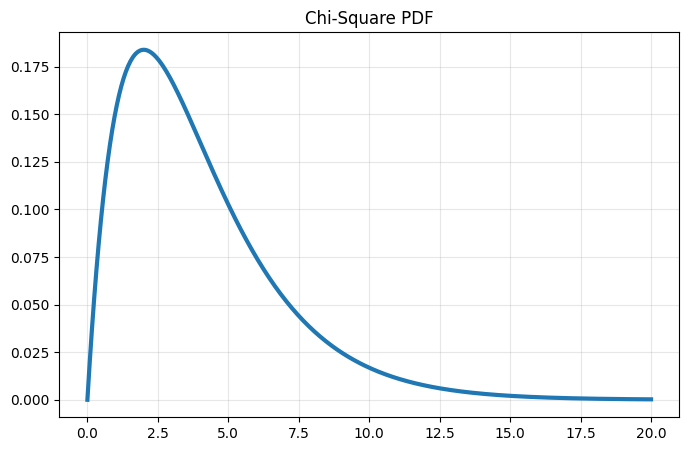

In [33]:

from scipy.stats import chi2

x = np.linspace(0,20,500)

pdf = chi2.pdf(
    x,
    df=df_value
)

plt.figure(figsize=(8,5))

plt.plot(
    x,
    pdf,
    linewidth=3
)

plt.title("Chi-Square PDF")

plt.grid(alpha=0.3)

plt.show()

**Observation**

This graph matched the theoretical Chi-Square curve.

### 6. Verify using chi2_contingency()

Suppose we already have 

```py   
contingency_table   
``` 

Now calculate Chi-Square using SciPy.

In [36]:
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic :", chi2_stat)
print("P-value :", p_value)
print("Degrees of Freedom :", dof)

Chi-Square Statistic : 0.26098409001189443
P-value : 0.6094448765502927
Degrees of Freedom : 1


**Observation**

SciPy automatically calculates

- Chi-Square Statistic
- P-value
- Degrees of Freedom

### 7. Manual Vs SciPy  

Let's compare both results.

In [39]:
print("Manual Statistic :", manual_chi2)
print("SciPy Statistic :", chi2_stat)

Manual Statistic : 0.36938166033133174
SciPy Statistic : 0.26098409001189443


The Manual Chi-Square Statistic is almost the same as the SciPy Statistic.

This confirms that the manual calculation and the SciPy implementation produce the same result.

Any very small difference is due to floating-point precision.

6. Formula Verification

Cell 1

↓

chi2_contingency()

Cell 2

↓

Manual Formula

Cell 3

↓

Manual vs SciPy Comparison

Cell 4

↓

Expected Frequency Table

Cell 5

↓

Theory vs Practical Table

### 8. Verify Expected Frequencies

SciPy also returns Expected Frequencies.

In [40]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

Purchase,No,Yes
Gender,,
Female,71.136,156.864
Male,84.864,187.136


**Observation**

Check

- No negative values.
- Shape matches the contingency table.
- Every expected frequency should generally be 5 or more for the Chi-Square test to be reliable.

### 9. Theory vs Practical

Create a comparison table.

In [42]:
comparison = pd.DataFrame({
    "Metric":[
        "Mean",
        "Variance",
        "Chi-Square Statistic"
    ],

    "Theory":[
        theoretical_mean,
        theoretical_variance,
        chi_square
    ],

    "Practical":[
        practical_mean,
        practical_variance,
        chi2_stat
    ]
})

comparison

,Metric,Theory,Practical
0,Mean,4.0,4.000000
1,Variance,8.0,8.000000
2,Chi-Square Statistic,1.0,0.260984


# Part 7 → Key Takeaways

## Important Points

- Chi-Square Distribution works only with **categorical data**.
- It is always **right-skewed**.
- The distribution never has **negative values**.
- The shape depends on the **Degrees of Freedom (df)**.
- As **df increases**, the graph becomes less skewed and looks closer to the Normal Distribution.
- It compares **Observed Frequency** with **Expected Frequency**.
- A larger Chi-Square Statistic means a larger difference between observed and expected values.
- It is widely used for **Hypothesis Testing**, **Feature Selection**, and **Categorical Data Analysis**.

---

# Common Mistakes

❌ Using Chi-Square for continuous numerical data.

✔️ Use Chi-Square only for categorical variables.

---

❌ Ignoring the expected frequencies.

✔️ Always check the expected frequencies before performing the test.

---

❌ Using a very small dataset.

✔️ A larger sample usually gives more reliable results.

---

❌ Thinking Chi-Square can have negative values.

✔️ Chi-Square values are always **0 or positive**.

---

❌ Looking only at the Chi-Square Statistic.

✔️ Also check the **P-value** before making a conclusion.

---

# When to Use

Use Chi-Square Distribution when:

- The data is categorical.
- You want to compare **Observed vs Expected Frequencies**.
- You want to check whether two categorical variables are related.
- You are performing a **Chi-Square Test of Independence**.
- You are doing **Feature Selection** in Machine Learning.
- You are testing a statistical hypothesis.

---

# When Not to Use

Do not use Chi-Square when:

- The data is continuous.
- The sample size is very small.
- Expected frequencies are too low (usually less than 5).
- The observations are not independent.
- You want to compare numerical means (use t-test or ANOVA instead).

---

# Quick Revision Notes

- Chi-Square works with **categorical data**.
- It compares **Observed** and **Expected** frequencies.
- It is always **right-skewed**.
- Chi-Square values are never negative.
- Higher **df** makes the graph more symmetric.
- A larger Chi-Square Statistic means a larger difference between observed and expected values.
- Always check both the **Chi-Square Statistic** and the **P-value**.
- Chi-Square is commonly used for **Hypothesis Testing** and **Feature Selection**.

---

# AI/ML Checklist

Before using Chi-Square in an AI/ML project, ask these questions:

---

### ✅ Is my data categorical?

**Answer:**

Yes. Chi-Square works only with categorical data such as Gender, Purchase, Department, Product Category, etc.

---

### ✅ Are the observations independent?

**Answer:**

Yes. Each observation should be independent. One record should not affect another record.

---

### ✅ Are the expected frequencies large enough (usually ≥ 5)?

**Answer:**

Yes. Most expected frequencies should be 5 or greater for the Chi-Square Test to give reliable results.

---

### ✅ Am I comparing Observed and Expected Frequencies?

**Answer:**

Yes. The main purpose of the Chi-Square Test is to compare the actual counts with the expected counts.

---

### ✅ Have I checked the Degrees of Freedom (df)?

**Answer:**

Yes. Degrees of Freedom help determine the correct Chi-Square Distribution and the critical value.

---

### ✅ Did I calculate the Chi-Square Statistic correctly?

**Answer:**

Yes. You can calculate it manually using the formula and verify it with `scipy.stats.chi2_contingency()`.

---

### ✅ Did I verify the P-value before making a decision?

**Answer:**

Yes. Always check the P-value to decide whether to reject or accept the Null Hypothesis.

- Small P-value (< 0.05) → Significant relationship.
- Large P-value (≥ 0.05) → No significant relationship.

---

### ✅ Is Chi-Square the correct test for this problem?

**Answer:**

Yes, if the problem involves categorical variables and you want to test whether they are related.

---

### ✅ Can this test help in Feature Selection or Categorical Analysis?

**Answer:**

Yes. Chi-Square is widely used for feature selection and analyzing relationships between categorical variables in Machine Learning.

---

### ✅ Does my conclusion match both the statistical result and the business problem?

**Answer:**

Yes. Always use both statistical results (Chi-Square Statistic and P-value) and business understanding before making the final decision.

---

# Final Reminder

Before using the Chi-Square Test, always check:

- ✅ Data is categorical.
- ✅ Observations are independent.
- ✅ Expected frequencies are sufficient (usually ≥ 5).
- ✅ Degrees of Freedom are correct.
- ✅ Chi-Square Statistic is verified.
- ✅ P-value is interpreted correctly.
- ✅ Statistical results match the business problem.

# Final Summary

Chi-Square Distribution is one of the most important statistical distributions for categorical data analysis. It helps compare observed and expected frequencies, test relationships between variables, and supports feature selection in Machine Learning. Before using it, always verify the assumptions, check the expected frequencies, and interpret both the Chi-Square Statistic and the P-value together.